# Class 27: Scipy: Model Fitting
## Objective: Understand model fitting and usage of scipy tools

These exercises are based on those in "Lecture 18: Scipy: Optimization and Curve Fitting" by Yuan-Sen Ting and available from https://tingyuansen.github.io/coding_essential_for_astronomers/lectures/lecture18-scipy-optimization-curve-fitting.html

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, optimize

# Plotting defaults
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## Section 1: Sample Measurements and True Values

The mean of a collection of measurements (called the **sample mean**) is only an estimate of the **true mean** of the underlying distribution. This is because measurements are never perfect (have zero uncertainty). In addition, the objects we measure may be intrinsically variable. 

For example, imagine we observe a star 50 times and take the mean of those measurements. This gives us 50 measurements $x_i$ (where $i=1-50$) and each has some uncertainty $\sigma_i$. The sample mean is the weighted mean of these numbers. 

The more measurements we make and/or the more precise our measurements, the closer the sample mean will be to the true mean. 

True brightness: 10.50 magnitudes
Measurement uncertainty: 0.20 magnitudes
Number of observations: 50

First 10 observations:
  Night  1: 10.599 mag
  Night  2: 10.472 mag
  Night  3: 10.630 mag
  Night  4: 10.805 mag
  Night  5: 10.453 mag
  Night  6: 10.453 mag
  Night  7: 10.816 mag
  Night  8: 10.653 mag
  Night  9: 10.406 mag
  Night 10: 10.609 mag


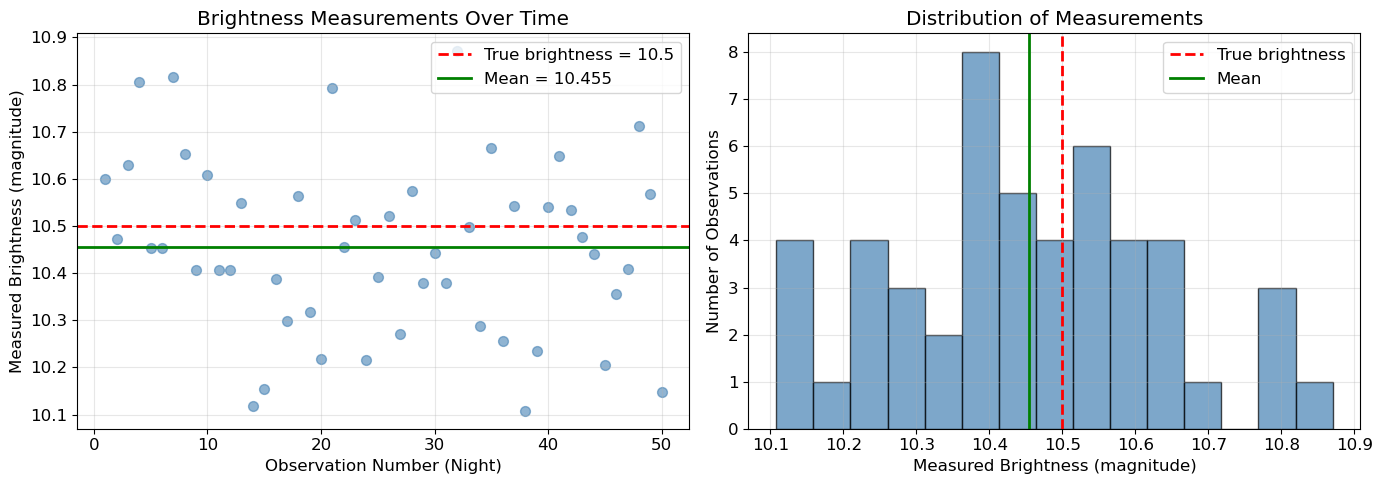

In [3]:
# Set random seed for reproducibility
np.random.seed(42)

# Define the star's true properties
true_brightness = 10.5  # True magnitude (the value we're trying to find)
n_observations = 50      # Number of nights we observed the star
measurement_error = 0.2  # Typical measurement uncertainty in magnitudes

# Generate noisy observations by adding random noise to the true brightness
noise = np.random.normal(loc=0, scale=measurement_error, size=n_observations)
observations = true_brightness + noise

# Display some sample observations
print(f"True brightness: {true_brightness:.2f} magnitudes")
print(f"Measurement uncertainty: {measurement_error:.2f} magnitudes")
print(f"Number of observations: {n_observations}")
print(f"\nFirst 10 observations:")
for i in range(10):
    print(f"  Night {i+1:2d}: {observations[i]:.3f} mag")

# Create two subplots to visualize the data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: measurements vs observation number (time series)
nights = np.arange(1, n_observations + 1)
ax1.scatter(nights, observations, alpha=0.6, s=50, color='steelblue')
ax1.axhline(true_brightness, color='red', linestyle='--', linewidth=2, 
            label=f'True brightness = {true_brightness}')
ax1.axhline(np.mean(observations), color='green', linestyle='-', linewidth=2,
            label=f'Mean = {np.mean(observations):.3f}')
ax1.set_xlabel('Observation Number (Night)')
ax1.set_ylabel('Measured Brightness (magnitude)')
ax1.set_title('Brightness Measurements Over Time')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right plot: histogram showing the distribution of measurements
ax2.hist(observations, bins=15, edgecolor='black', alpha=0.7, color='steelblue')
ax2.axvline(true_brightness, color='red', linestyle='--', linewidth=2,
            label='True brightness')
ax2.axvline(np.mean(observations), color='green', linestyle='-', linewidth=2,
            label='Mean')
ax2.set_xlabel('Measured Brightness (magnitude)')
ax2.set_ylabel('Number of Observations')
ax2.set_title('Distribution of Measurements')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Test your understanding:** 
Experiment by adjusting the measurement error `measurement_error` and the number of observations `n_observations`. Think about how you expect the results to change before you plot the output.

## Section 2: Connection to Optimization

The sample mean is not just a guess at the true mean. It is the *best guess* in a statistical sense. 

A good way to define what *best guess* means is in terms of a **cost function**. A cost function is a function that quantifies how incorrect a guess is. 

A common choice for a cost function is the **chi-squared** ($\chi^2$) $\chi^2$ statistic. The $\chi^2$ function calculates the differences between each measurement and a guess. For this case, each measurement is $x_i$ with uncertainty $\sigma_i$ and our guess for the mean is $\mu$. The value of $\chi^2$ is the quadrature sum of these differences: 

$$
\chi^2 = \sum^n_{i=1} \left( \frac{x_i - \mu}{\sigma_i} \right)^2
$$

In [4]:
def cost_function(mean_guess, measurements=observations, measurement_error=measurement_error):
    """
    Calculate chi-squared for an estimate of the mean.
    
    This function quantifies how a guess agrees with all 
    our measurements, properly accounting for measurement uncertainties.
    
    Parameters:
    -----------
    mean_guess : float
        The proposed value
    
    Returns:
    --------
    float
        The chi-squared value (lower is better)
    """
    # Calculate the difference between each observation and our guess
    residuals = measurements - mean_guess
    
    # Calculate chi-squared: sum of squared residuals weighted by uncertainties
    # Dividing by measurement_error gives more weight to precise observations
    # In this example, all errors are equal (0.2 mag), so all observations
    # have equal weight - but we include sigma to show the proper form
    chi_squared = np.sum((residuals / measurement_error)**2)
    
    return chi_squared


# Test the cost function with different brightness guesses
test_guesses = [10.0, 10.3, 10.5, 10.7, 11.0]

print("Testing the cost function with different brightness guesses:")
print("=" * 50)

# The < and > symbols control text alignment in f-string formatting:
# <25 means left-align within 25 characters
# >15 means right-align within 15 characters
print(f"{'Guess (mag)':<20} {'chi^2':>15}")
print("=" * 50)

for guess in test_guesses:
    cost = cost_function(guess, observations, measurement_error)
    print(f"  {guess:5.1f}                    {cost:8.3f}")

print("=" * 50)

Testing the cost function with different brightness guesses:
Guess (mag)                    chi^2
   10.0                     301.389
   10.3                      72.710
   10.5                      45.257
   10.7                     117.804
   11.0                     414.126


The best value is the one that has the lowest cost, or the lowest value of $\chi^2$. The identification of the best value is consequently the same as finding the minimum value of $\chi^2. 

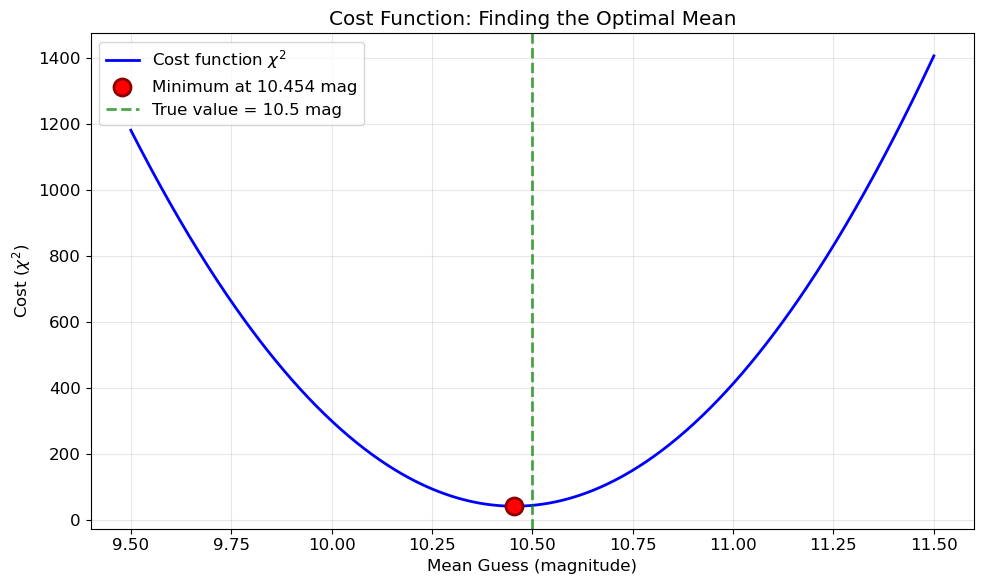


Minimum cost found at brightness = 10.4539 mag
For comparison, mean of observations = 10.4549 mag


In [5]:
# Create a finer grid of possible brightness values
guess_grid = np.linspace(9.5, 11.5, 500)

# Calculate the cost at each point on the grid
costs = np.array([cost_function(g, observations, measurement_error) for g in guess_grid])

# Plot the cost function
plt.figure(figsize=(10, 6))

# Plot cost vs brightness
plt.plot(guess_grid, costs, 'b-', linewidth=2, label=r'Cost function $\chi^2$')

# Mark the minimum we can find from our grid
min_index = np.argmin(costs)
optimal_mean = guess_grid[min_index]
min_cost = costs[min_index]

plt.scatter(optimal_mean, min_cost, color='red', s=150, zorder=5,
           marker='o', edgecolors='darkred', linewidth=2,
           label=f'Minimum at {optimal_mean:.3f} mag')

# Mark the true mean for reference
plt.axvline(true_brightness, color='green', linestyle='--', alpha=0.7, 
           linewidth=2, label=f'True value = {true_brightness} mag')

plt.xlabel('Mean Guess (magnitude)')
plt.ylabel('Cost ($\chi^2$)')
plt.title('Cost Function: Finding the Optimal Mean')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nMinimum cost found at brightness = {optimal_mean:.4f} mag")
print(f"For comparison, mean of observations = {np.mean(observations):.4f} mag")

**Test your understanding:** The optimal value of the mean is at the minimum of the cost function. Compute and plot the numerical derivative of the `costs` to determine if there is a minimum at the optimal value of the mean.

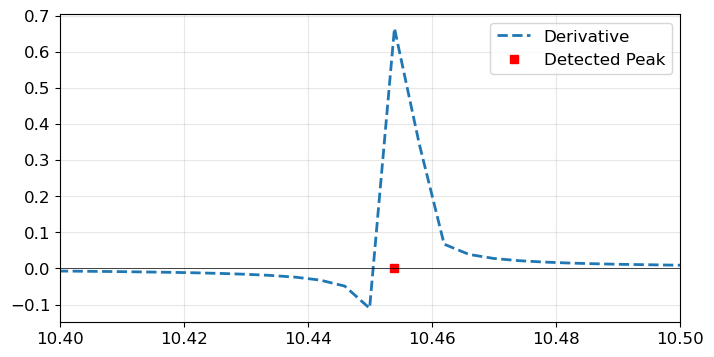

In [6]:
# Enter your code here

# Calculate the numerical derivative 
dchi2_dx = np.gradient(guess_grid, costs)

# Find where the derivative is approximately zero (Extrema)
peaks = np.where(np.diff(np.sign(dchi2_dx)) < 0)[0]

plt.figure(figsize=(8, 4))
plt.plot(guess_grid, dchi2_dx, '--', label='Derivative') 
plt.plot(optimal_mean, 0., 'rs', label="Detected Peak")
plt.axhline(0, color='black', lw=0.5)
plt.xlim(10.4, 10.5)
plt.legend()
plt.show()

## Section 3: Optimization Tools - Single Scalar

The previous section showed that the minimum value of $\chi^2$ is at the same value as the weighted mean. This is not a coincidence. You can derive the formula for the weighted mean by solving for the value of the mean where $\chi^2$ is a minimum.

The weighted mean is a particularly simple model that we fit to the data: it is a single parameter model, where the single parameter is the weighted mean.

The use of a cost function like $\chi^2$ is much more powerful when we have models with multiple parameters, especially when there is not an analytic formula for their values (like there is for the weighted mean). This is because the minimum value of $\chi^2$ still corresponds to the best set of model parameters.  

There are large numbers of algorithms that are focused on identifying the best set of model parameters by very efficiently identifying the model parameters that correspond to the minimum value of $\chi^2$. 

Before we look at multiple parameter models, let's look at the performance of the `minimum_scalar` function in `scipy.optimization` on the calculation of the mean. By default, this uses an algorithm called *Brent's Method* to find the minimum. The output is an `OptimizeResult` object. 

Take note of the number of function evaluations and iterations compared to the 500 equally-spaced values shown in the plot above.

In [7]:
# Import the minimize_scalar function
from scipy.optimize import minimize_scalar

# Use Brent's method to find the minimum (no bounds needed)
result = minimize_scalar(cost_function)

# Display the optimization results
print("Optimization Results (Brent's Method):")
print("=" * 50)
print(f"Success: {result.success}")
print(f"Optimal brightness: {result.x:.6f} mag")
print(f"Minimum cost: {result.fun:.6f}")
print(f"Number of function evaluations: {result.nfev}")
print(f"Number of iterations: {result.nit}")
print("\nFor comparison:")
print(f"Mean of observations: {np.mean(observations):.6f} mag")
print(f"True brightness: {true_brightness:.6f} mag")

Optimization Results (Brent's Method):
Success: True
Optimal brightness: 10.454905 mag
Minimum cost: 42.715132
Number of function evaluations: 9
Number of iterations: 4

For comparison:
Mean of observations: 10.454905 mag
True brightness: 10.500000 mag


**Test your understanding:** 
Optimization routines work even faster if you already have some information about what you expect. The `minimize_scalar` function has a `bracket` parameter that can be used to define to set an interval for the correct answer `bracket=(xa,xb)` or an interval and initial guess `bracket=(xa,xb,xc)`. Experiment with using this parameter and see how this impacts the number of function evaluations and number of iterations. 

In [8]:
# Enter your code here



## Section 4: Multiple Parameters

The optimization algorithms are extremely powerful and useful when there are multiple parameters. 

The processing of fitting multiple parameters is often referred to as **curve fitting** or **regression**. 

We'll first create a simulated dataset with a star moving with time.

Observing a star moving across the sky
True initial position: 100.0 milliarcseconds
True velocity: 5.0 milliarcseconds/year
Observation span: 4.0 years
Number of observations: 20

Sample observations:
Time (years)    Position (mas)       Error (mas)     True Position (mas) 
0.00            100.82               1.67            100.00              
0.21            100.75               2.41            101.05              
0.42            105.40               1.70            102.11              
0.63            102.01               1.86            103.16              
0.84            102.13               1.99            104.21              
...


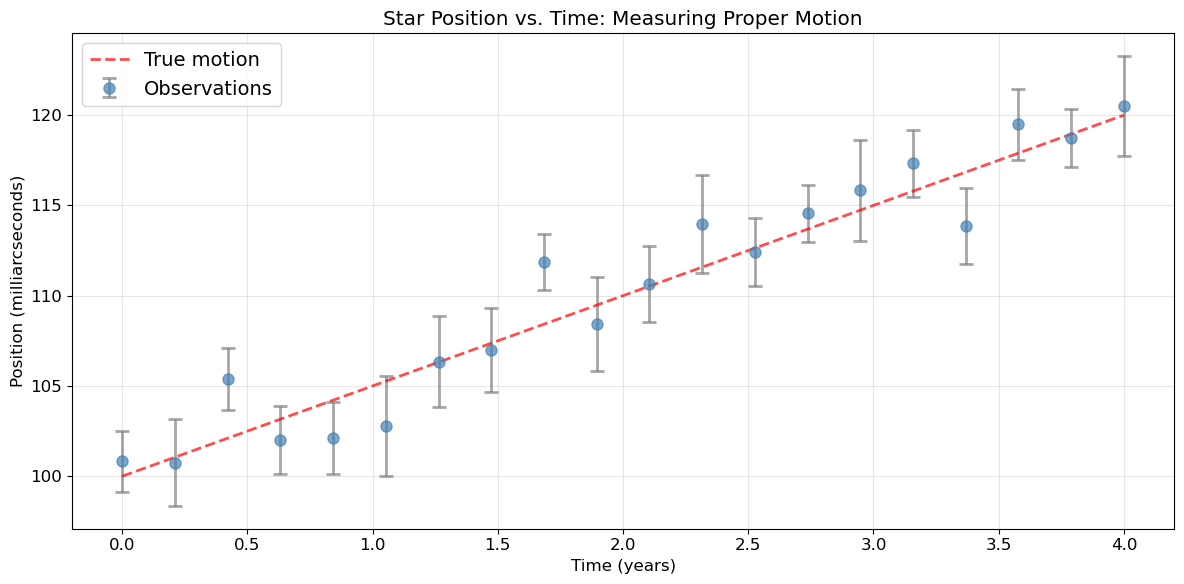

In [9]:
# True parameters of the moving star
true_position0 = 100.0  # Initial position in milliarcseconds
true_velocity = 5.0      # Velocity in milliarcseconds per year

# Observation times (in years)
n_obs = 20
observation_times = np.linspace(0, 4, n_obs)  # Observe over 4 years

print(f"Observing a star moving across the sky")
print(f"True initial position: {true_position0} milliarcseconds")
print(f"True velocity: {true_velocity} milliarcseconds/year")
print(f"Observation span: {observation_times[-1]} years")
print(f"Number of observations: {n_obs}")

# Calculate the true position at each observation time
true_positions = true_position0 + true_velocity * observation_times

# Generate inhomogeneous measurement errors
# In real astronomy, observation quality varies due to weather, telescope pointing, etc.
# We'll simulate errors ranging from 1.5 to 3.0 milliarcseconds
np.random.seed(43)  # Different seed for errors
position_errors = np.random.uniform(1.5, 3.0, n_obs)

# Add measurement noise according to each observation's uncertainty
noise = np.array([np.random.normal(0, sigma) for sigma in position_errors])
observed_positions = true_positions + noise

# Display some observations with their uncertainties
print("\nSample observations:")
print(f"{'Time (years)':<15} {'Position (mas)':<20} {'Error (mas)':<15} {'True Position (mas)':<20}")
print("=" * 70)
for i in range(5):
    print(f"{observation_times[i]:<15.2f} {observed_positions[i]:<20.2f} {position_errors[i]:<15.2f} {true_positions[i]:<20.2f}")
print("...")

# Plot the observations
plt.figure(figsize=(12, 6))

# Plot observations with error bars (note that error bar sizes vary!)
plt.errorbar(observation_times, observed_positions, yerr=position_errors,
             fmt='o', markersize=8, capsize=5, capthick=2, alpha=0.7,
             color='steelblue', ecolor='gray', label='Observations')

# Plot the true motion for comparison
plt.plot(observation_times, true_positions, 'r--', linewidth=2,
        alpha=0.7, label='True motion')

plt.xlabel('Time (years)')
plt.ylabel('Position (milliarcseconds)')
plt.title('Star Position vs. Time: Measuring Proper Motion')
plt.legend(fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Now we will create a linear model for the star's position as a function of time. 

The input (also called the independent variable) is the time, the two parameters are the initial position and velocity, and the output (also called dependent variable) is the predicted position.

We use `scipy.optimize.curve_fit` to determine the optimal values of the two parameters given the time values and observed positions. 

Linear Fit Results:
Fitted initial position: 100.635 mas
Fitted velocity: 4.925 mas/year

True values:
True initial position: 100.000 mas
True velocity: 5.000 mas/year


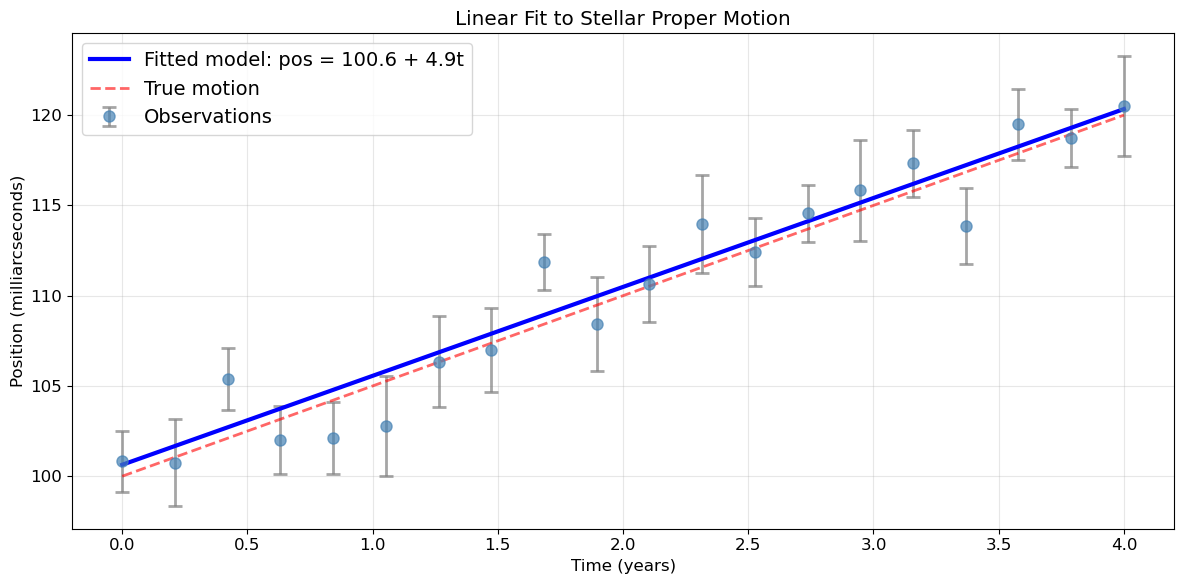

In [10]:
def linear_model(time, position0, velocity):
    """
    Model for linear stellar motion.
    
    This function calculates the predicted position of a star
    at any given time, based on its initial position and velocity.
    
    Parameters:
    -----------
    time : array-like
        Time values in years (this is the independent variable)
    position0 : float
        Initial position in milliarcseconds (parameter to fit)
    velocity : float
        Velocity in milliarcseconds per year (parameter to fit)
    
    Returns:
    --------
    array
        Predicted positions at each time
    """
    return position0 + velocity * time

# Import curve_fit
from scipy.optimize import curve_fit

# Fit the linear model to our observations
# We provide the measurement uncertainties via sigma - this weights the fit!
popt, pcov = curve_fit(
    linear_model,          # The model function
    observation_times,     # Independent variable (x-values)
    observed_positions,    # Dependent variable (y-values)
    sigma=position_errors, # Measurement uncertainties for each observation
    absolute_sigma=True    # Treat sigma as absolute errors (not relative)
)

# Extract the fitted parameters
fitted_position0, fitted_velocity = popt

print("Linear Fit Results:")
print("=" * 50)
print(f"Fitted initial position: {fitted_position0:.3f} mas")
print(f"Fitted velocity: {fitted_velocity:.3f} mas/year")
print("\nTrue values:")
print(f"True initial position: {true_position0:.3f} mas")
print(f"True velocity: {true_velocity:.3f} mas/year")

# Calculate the fitted model line
fitted_positions = linear_model(observation_times, fitted_position0, fitted_velocity)

# Create a smooth curve for plotting
time_smooth = np.linspace(0, 4, 200)
fitted_curve_smooth = linear_model(time_smooth, fitted_position0, fitted_velocity)

# Create the plot
plt.figure(figsize=(12, 6))

# Plot observations with their varying error bars
plt.errorbar(observation_times, observed_positions, yerr=position_errors,
             fmt='o', markersize=8, capsize=5, capthick=2, alpha=0.7,
             color='steelblue', ecolor='gray', label='Observations')

# Plot fitted model
plt.plot(time_smooth, fitted_curve_smooth, 'b-', linewidth=3,
        label=rf'Fitted model: pos = {fitted_position0:.1f} + {fitted_velocity:.1f}t')

# Plot true motion for comparison
true_curve_smooth = linear_model(time_smooth, true_position0, true_velocity)
plt.plot(time_smooth, true_curve_smooth, 'r--', linewidth=2, alpha=0.6,
        label='True motion')

plt.xlabel('Time (years)')
plt.ylabel('Position (milliarcseconds)')
plt.title('Linear Fit to Stellar Proper Motion')
plt.legend(fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Test your understanding**
Explore how the agreement between the model and the true changes with more or fewer points. Explore how the model performs relative to the truth if you extrapolate both into the future (or past). 

## Section 5: Parameter Uncertainties and the Covariance Matrix

Parameter values have uncertainties. These uncertainties depend on multiple factors:
- Size of the measurement errors
- Number of measurements
- Quality of the model

In addition to their individual uncertainties, the model uncertainties in the model parameters can be correlated (or anti-correlated) with each other.

For example, if the model overestimates the initial position, it will simultaneously underestimate the velocity. 

The parameter uncertainties and their correlations are described by the **Covariance Matrix**. This is a square matrix with the same number of dimensions (rows and columns) as parameters and is symmetric with respect to the diagonal. 

The elements on the diagonal are the variances of the individual parameters and the off-diagonal elements (covariance) are the degree of correlation between them. 


In [11]:
# Print the covariance matrix from the previous fit

print("Covariance Matrix:") 
print(pcov)
print("=" * 50)

# Extract parameter uncertainties from the covariance matrix
# np.diag() extracts the diagonal elements (the variances)
# np.sqrt() takes the square root to get standard deviations
parameter_uncertainties = np.sqrt(np.diag(pcov))

# Extract individual uncertainties
position0_error = parameter_uncertainties[0]
velocity_error = parameter_uncertainties[1]

print("Parameter Uncertainties:")
print(f"Initial position: {fitted_position0:.3f} ± {position0_error:.3f} mas")
print(f"Velocity: {fitted_velocity:.3f} ± {velocity_error:.3f} mas/year")

Covariance Matrix:
[[ 0.71441898 -0.2585069 ]
 [-0.2585069   0.1306597 ]]
Parameter Uncertainties:
Initial position: 100.635 ± 0.845 mas
Velocity: 4.925 ± 0.361 mas/year


**Test your understanding:** Connect the covariance matrix to the uncertainties in the parameters

## Section 6: Non-linear Curve Fitting

One common non-linear model fitting case is analyzing binary star systems. 

We often do not resolve the stars in a binary system because most are too far away. However, we are able to spectroscopically measure radial velocity changes for one (or sometimes both) members of a binary. 

If the orbit is circular, the measured radial velocity for a star as a function of time is 

$$
v_r(t) = v_{sys} + K + \sin \left( \frac{2 \pi}{P} (t - t_0) \right)
$$

The measured amplitude $K$ depends the intrinsic conditions of the binary (mass ratio, separataion) and on the extrinsic nature of the system (inclination angle of the binary system relative to our perspective or line of sight). 

More massive and closer binaries will produce larger orbital velocities. In addition, the close we observe the binary system to edge-on, the greater the apparent orbital velocities. 

In [12]:
# True orbital parameters of the binary system
true_K = 45.0           # Semi-amplitude in km/s
true_P = 5.7            # Orbital period in days
true_t0 = 1.2           # Reference time in days
true_vsys = -15.0       # Systemic velocity in km/s

print("Binary Star System Parameters:")
print("=" * 50)
print(f"Orbital period: {true_P} days")
print(f"Velocity semi-amplitude: {true_K} km/s")
print(f"Systemic velocity: {true_vsys} km/s")
print(f"Reference time: {true_t0} days")

# Simulate realistic observation times over 20 days
n_obs = 30
observation_times = np.sort(np.random.uniform(0, 20, n_obs))

print(f"\nObservation campaign:")
print(f"  Duration: {observation_times[-1]:.1f} days")
print(f"  Number of observations: {n_obs}")
print(f"  Number of orbital cycles covered: {observation_times[-1]/true_P:.1f}")

def radial_velocity_model(t, K, P, t0, vsys):
    """
    Radial velocity model for a binary star in circular orbit.
    
    Parameters:
    -----------
    t : array-like
        Time values in days (independent variable)
    K : float
        Semi-amplitude in km/s (parameter to fit)
    P : float
        Orbital period in days (parameter to fit)
    t0 : float
        Reference time in days (parameter to fit)
    vsys : float
        Systemic velocity in km/s (parameter to fit)
    
    Returns:
    --------
    array
        Radial velocities at each time in km/s
    """
    # Calculate the orbital phase at each time
    phase = 2 * np.pi * (t - t0) / P
    
    # Calculate radial velocity: systemic velocity + orbital variation
    return vsys + K * np.sin(phase)

# Calculate true radial velocities
true_velocities = radial_velocity_model(observation_times, true_K, true_P, true_t0, true_vsys)

# Generate heterogeneous measurement uncertainties
# Spectroscopy quality varies due to weather, exposure time, stellar brightness, etc.
np.random.seed(45)  # Different seed for velocity errors
velocity_errors = np.random.uniform(0.5, 1.5, n_obs)  # Range of typical RV uncertainties in km/s

# Add measurement noise according to each observation's uncertainty
noise = np.array([np.random.normal(0, sigma) for sigma in velocity_errors])
observed_velocities = true_velocities + noise

print("Sample observations:")
print(f"{'Time (days)':<15} {'Velocity (km/s)':<20} {'Error (km/s)':<15}")
print("=" * 50)
for i in range(5):
    print(f"{observation_times[i]:<15.2f} {observed_velocities[i]:<20.2f} {velocity_errors[i]:<15.3f}")
print("...")
print(f"\nVelocity uncertainties range: {velocity_errors.min():.3f} to {velocity_errors.max():.3f} km/s")

Binary Star System Parameters:
Orbital period: 5.7 days
Velocity semi-amplitude: 45.0 km/s
Systemic velocity: -15.0 km/s
Reference time: 1.2 days

Observation campaign:
  Duration: 19.9 days
  Number of observations: 30
  Number of orbital cycles covered: 3.5
Sample observations:
Time (days)     Velocity (km/s)      Error (km/s)   
2.05            20.47                1.489          
2.89            28.45                1.050          
3.98            -12.90               0.781          
4.12            -17.59               0.577          
4.87            -50.77               0.944          
...

Velocity uncertainties range: 0.549 to 1.491 km/s


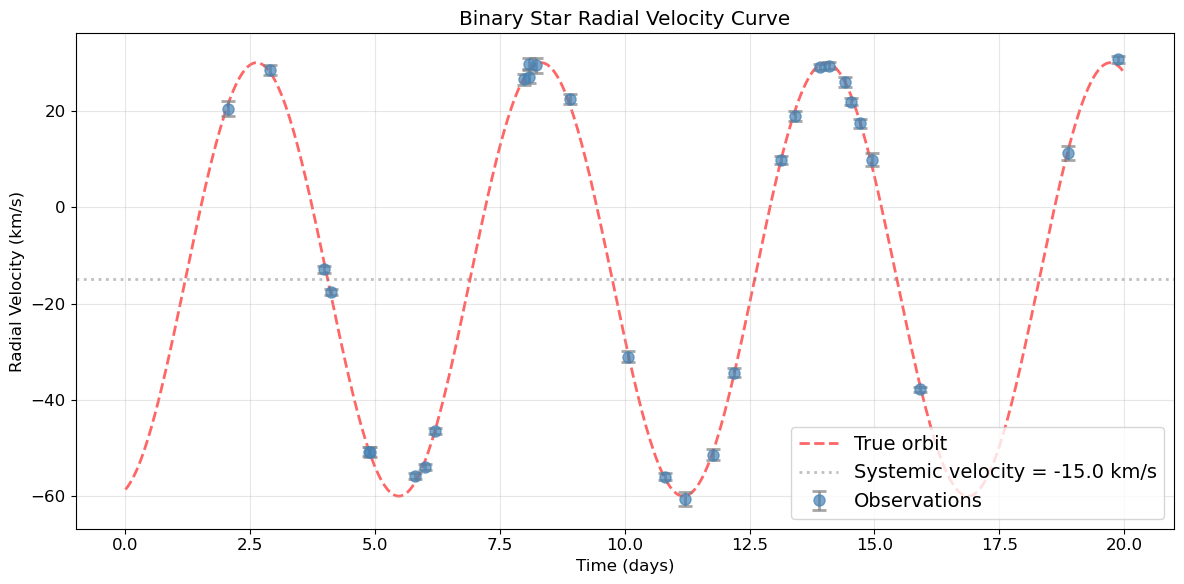

In [13]:
# Create smooth curve for visualization
time_smooth = np.linspace(0, 20, 500)
true_rv_curve = radial_velocity_model(time_smooth, true_K, true_P, true_t0, true_vsys)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot observations with varying error bars
ax.errorbar(observation_times, observed_velocities, yerr=velocity_errors,
           fmt='o', markersize=8, capsize=5, capthick=2, alpha=0.7,
           color='steelblue', ecolor='gray', label='Observations', zorder=3)

# Plot true orbit
ax.plot(time_smooth, true_rv_curve, 'r--', linewidth=2, alpha=0.6,
       label='True orbit', zorder=1)

# Mark systemic velocity
ax.axhline(true_vsys, color='gray', linestyle=':', linewidth=2, alpha=0.5,
          label=f'Systemic velocity = {true_vsys} km/s')

ax.set_xlabel('Time (days)')
ax.set_ylabel('Radial Velocity (km/s)')
ax.set_title('Binary Star Radial Velocity Curve')
ax.legend(fontsize=14, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Initial parameter guesses:
Semi-amplitude K: 45.7 km/s
Period P: 6.0 days
Reference time t0: 2.1 days
Systemic velocity vsys: -5.7 km/s
Fitted Orbital Parameters:
Semi-amplitude K:
  Fitted: 44.94 km/s
  True:   45.00 km/s

Orbital period P:
  Fitted: 5.694 days
  True:   5.700 days

Reference time t0:
  Fitted: 1.209 days
  True:   1.200 days

Systemic velocity vsys:
  Fitted: -15.03 km/s
  True:   -15.00 km/s

Parameter Uncertainties:
Semi-amplitude K: 44.94 ± 0.20 km/s
Period P: 5.694 ± 0.006 days
Reference time t0: 1.209 ± 0.010 days
Systemic velocity vsys: -15.03 ± 0.16 km/s

These uncertainties tell us how precisely we've determined each parameter.


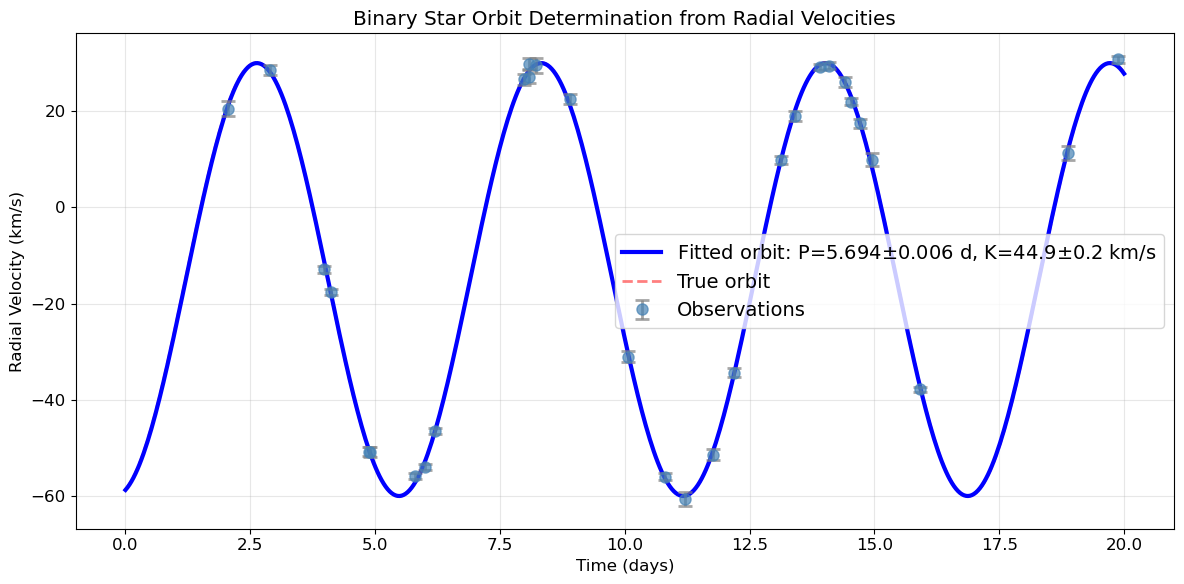

In [14]:
# Estimate initial parameters from observations
# Systemic velocity: approximately the mean radial velocity
initial_vsys = np.mean(observed_velocities)

# Semi-amplitude: approximately half the peak-to-peak variation
initial_K = (np.max(observed_velocities) - np.min(observed_velocities)) / 2

# Period: harder to estimate by eye, but we can guess a reasonable value
# Looking at the pattern, we see a few complete cycles in 20 days
initial_P = 6.0  # Rough guess

# Reference time: use the first observation time as starting point
initial_t0 = observation_times[0]

initial_params = [initial_K, initial_P, initial_t0, initial_vsys]

print("Initial parameter guesses:")
print("=" * 50)
print(f"Semi-amplitude K: {initial_K:.1f} km/s")
print(f"Period P: {initial_P:.1f} days")
print(f"Reference time t0: {initial_t0:.1f} days")
print(f"Systemic velocity vsys: {initial_vsys:.1f} km/s")

# Fit the radial velocity curve
# We include measurement errors via the sigma parameter
# This weights the observations properly - more precise measurements have more influence
popt2, pcov2 = curve_fit(
    radial_velocity_model,         # The model function
    observation_times,              # Independent variable (time)
    observed_velocities,            # Dependent variable (radial velocity)
    p0=initial_params,             # Initial parameter guesses
    sigma=velocity_errors,          # Measurement uncertainties (heterogeneous!)
    absolute_sigma=True,            # Treat sigma as absolute errors
    maxfev=5000                     # Maximum function evaluations
)

# Extract fitted parameters
fitted_K, fitted_P, fitted_t0, fitted_vsys = popt2

print("Fitted Orbital Parameters:")
print("=" * 50)
print(f"Semi-amplitude K:")
print(f"  Fitted: {fitted_K:.2f} km/s")
print(f"  True:   {true_K:.2f} km/s")
print(f"\nOrbital period P:")
print(f"  Fitted: {fitted_P:.3f} days")
print(f"  True:   {true_P:.3f} days")
print(f"\nReference time t0:")
print(f"  Fitted: {fitted_t0:.3f} days")
print(f"  True:   {true_t0:.3f} days")
print(f"\nSystemic velocity vsys:")
print(f"  Fitted: {fitted_vsys:.2f} km/s")
print(f"  True:   {true_vsys:.2f} km/s")

# Extract parameter uncertainties
param_uncertainties = np.sqrt(np.diag(pcov2))
K_err, P_err, t0_err, vsys_err = param_uncertainties

print("\nParameter Uncertainties:")
print("=" * 50)
print(f"Semi-amplitude K: {fitted_K:.2f} ± {K_err:.2f} km/s")
print(f"Period P: {fitted_P:.3f} ± {P_err:.3f} days")
print(f"Reference time t0: {fitted_t0:.3f} ± {t0_err:.3f} days")
print(f"Systemic velocity vsys: {fitted_vsys:.2f} ± {vsys_err:.2f} km/s")
print("\nThese uncertainties tell us how precisely we've determined each parameter.")

# Calculate fitted curve
fitted_rv_curve = radial_velocity_model(time_smooth, fitted_K, fitted_P, fitted_t0, fitted_vsys)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot observations with varying error bars
ax.errorbar(observation_times, observed_velocities, yerr=velocity_errors,
           fmt='o', markersize=8, capsize=5, capthick=2, alpha=0.7,
           color='steelblue', ecolor='gray', label='Observations', zorder=3)

# Plot fitted curve
ax.plot(time_smooth, fitted_rv_curve, 'b-', linewidth=3,
       label=f'Fitted orbit: P={fitted_P:.3f}$\pm${P_err:.3f} d, K={fitted_K:.1f}$\pm${K_err:.1f} km/s',
       zorder=2)

# Plot true curve for comparison
ax.plot(time_smooth, true_rv_curve, 'r--', linewidth=2, alpha=0.5,
       label='True orbit', zorder=1)

ax.set_xlabel('Time (days)')
ax.set_ylabel('Radial Velocity (km/s)')
ax.set_title('Binary Star Orbit Determination from Radial Velocities')
ax.legend(fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The amplitude and period are related to the mass ratio and inclination. The **mass function** is:

$$ 
f(M) = \frac{(M_2 \sin i)^3}{(M_1 + M_2)^2} = \frac{P K^3}{2\pi G}
$$

In [16]:
# Physical constants
G = 6.67430e-11  # Gravitational constant in m³ kg⁻¹ s⁻²
solar_mass = 1.989e30  # Solar mass in kg

# Convert fitted parameters to SI units
P_seconds = fitted_P * 86400  # Convert days to seconds
K_mps = fitted_K * 1000  # Convert km/s to m/s

# Calculate mass function: f(M) = (P $\times$ K³) / (2π $\times$ G)
mass_function_kg = (P_seconds * K_mps**3) / (2 * np.pi * G)
mass_function_solar = mass_function_kg / solar_mass

print("Mass Function Calculation:")
print("=" * 50)
print(f"From fitted parameters:")
print(f"  Period P = {fitted_P:.3f} days = {P_seconds:.0f} seconds")
print(f"  Semi-amplitude K = {fitted_K:.2f} km/s = {K_mps:.0f} m/s")
print(f"\nMass function:")
print(f"  f(M) = {mass_function_solar:.4f} solar masses")

Mass Function Calculation:
From fitted parameters:
  Period P = 5.694 days = 492005 seconds
  Semi-amplitude K = 44.94 km/s = 44943 m/s

Mass function:
  f(M) = 0.0535 solar masses


In [17]:
from scipy.optimize import fsolve

def mass_function_equation(M2, f_M, M1, sin_i):
    """
    Mass function equation to solve for companion mass M2.
    
    This function returns zero when M2 satisfies the mass function equation:
    f(M) = (M2 * sin(i))^3 / (M1 + M2)^2
    
    Parameters:
    -----------
    M2 : float
        Companion mass (in solar masses) - the variable we're solving for
    f_M : float
        Mass function value (in solar masses) from observations
    M1 : float
        Primary star mass (in solar masses) - assumed value
    sin_i : float
        Sine of orbital inclination - assumed value
    
    Returns:
    --------
    float
        Difference between calculated and observed mass function
        (zero when M2 is correct)
    """
    # Left side: mass function from observation
    left_side = f_M * (M1 + M2)**2
    
    # Right side: mass function from masses and inclination
    right_side = (M2 * sin_i)**3
    
    # Return difference (should be zero at the solution)
    return left_side - right_side
    
# Case 1: Edge-on orbit (i = 90°, sin i = 1), Sun-like primary
print("Solving for companion mass using fsolve:")
print("=" * 50)

M1_assumed = 1.0  # Solar masses
sin_i_assumed = 1.0  # Edge-on orbit
initial_guess = 0.8  # Starting guess for M2

M2_solution = fsolve(mass_function_equation, initial_guess, 
                     args=(mass_function_solar, M1_assumed, sin_i_assumed))[0]

print(f"\nCase 1: Edge-on orbit (i = 90°), M₁ = {M1_assumed:.1f} M☉")
print(f"  → M₂ = {M2_solution:.3f} M☉")

Solving for companion mass using fsolve:

Case 1: Edge-on orbit (i = 90°), M₁ = 1.0 M☉
  → M₂ = 0.492 M☉


**Test your understanding:**
Compute the solution for Case 2: An inclined orbit (i = 60°) with a Sun-like primary

## Solutions to In-Class Exercises

### Section 2 Solution

In [ ]:
# Calculate the numerical derivative 
dchi2_dx = np.gradient(guess_grid, costs)

# Find where the derivative is approximately zero (Extrema)
peaks = np.where(np.diff(np.sign(dchi2_dx)) < 0)[0]

plt.figure(figsize=(8, 4))
plt.plot(guess_grid, dchi2_dx, '--', label='Derivative') 
plt.plot(optimal_mean, 0., 'rs', label="Detected Peak")
plt.axhline(0, color='black', lw=0.5)
plt.xlim(10.4, 10.5)
plt.legend()
plt.show()

### Section 3 Solution

In [ ]:
# Pick a test range
test_range = (8, 13)

# Use Brent's method to find the minimum (no bounds needed)
result = minimize_scalar(cost_function, bracket=test_range)

# Display the optimization results
print("Optimization Results (Brent's Method):")
print("=" * 50)
print(f"Success: {result.success}")
print(f"Optimal brightness: {result.x:.6f} mag")
print(f"Minimum cost: {result.fun:.6f}")
print(f"Number of function evaluations: {result.nfev}")
print(f"Number of iterations: {result.nit}")
print("\nFor comparison:")
print(f"Mean of observations: {np.mean(observations):.6f} mag")
print(f"True brightness: {true_brightness:.6f} mag")

### Section 5 Solution

In [ ]:
# The values quoted above are:
# Initial position: 100.635 ± 0.845 mas
# Velocity: 4.925 ± 0.361 mas/year

# Compare them to the square root of the diagonal
print(np.sqrt(np.diag(pcov)))

### Section 6 Solution

In [ ]:
# Case 2: Inclined orbit (i = 60°), Sun-like primary
sin_i_60 = np.sin(np.radians(60))
initial_guess = 0.8

M2_solution_60 = fsolve(mass_function_equation, initial_guess,
                        args=(mass_function_solar, M1_assumed, sin_i_60))[0]

print(f"\nCase 2: Inclined orbit (i = 60°), M₁ = {M1_assumed:.1f} M☉")
print(f"  → M₂ = {M2_solution_60:.3f} M☉")
print(f"  (sin(60°) = {sin_i_60:.3f} means we see only 87% of orbital velocity)")